In [1]:
from models import SimpleCNN, ShallowCNN, ResidualCNN

summaries = {}
for name in models:
    df = pd.read_csv(f"Model_data/{name}_models_summary.csv")
    summaries[name] = df

summary_df = pd.concat(summaries.values())



plt.figure(figsize=(10,5))
sns.barplot(x="model", y="total_time_s", data=summary_df)
plt.title("Tổng thời gian huấn luyện của các mô hình")
plt.ylabel("Time (s)")
plt.show()


final_acc = []
for name, df in histories.items():
    acc = df["val_acc_pct"].iloc[-1]
    final_acc.append({"model": name, "final_acc_pct": acc})
acc_df = pd.DataFrame(final_acc)



plt.figure(figsize=(10,5))
ax = sns.barplot(x="model", y="final_acc_pct", data=acc_df)
plt.title("Validation Accuracy cuối cùng của các mô hình")
plt.ylabel("Accuracy (%)")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.show()


KeyboardInterrupt: 

In [2]:
def img_proccessing(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    
    img = cv2.resize(img, dsize=(224,224), interpolation=cv2.INTER_AREA)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    lap = cv2.Laplacian(img, cv2.CV_64F)
    img = cv2.addWeighted(img, 0.8, cv2.convertScaleAbs(lap), 0.2, 0)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

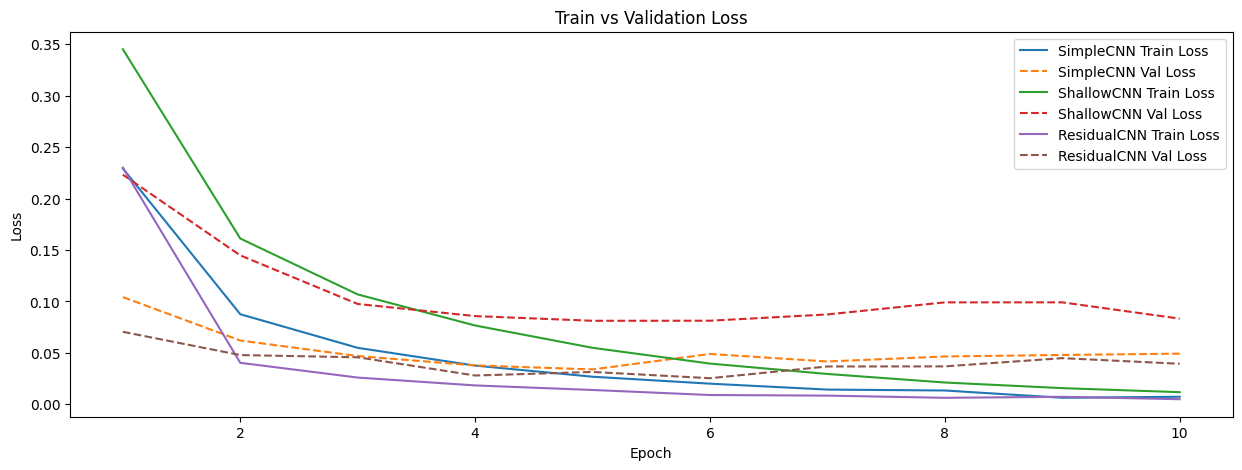

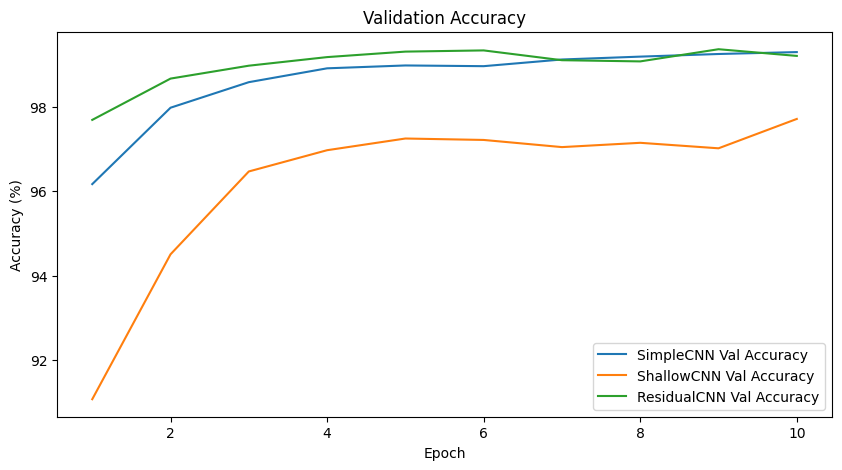

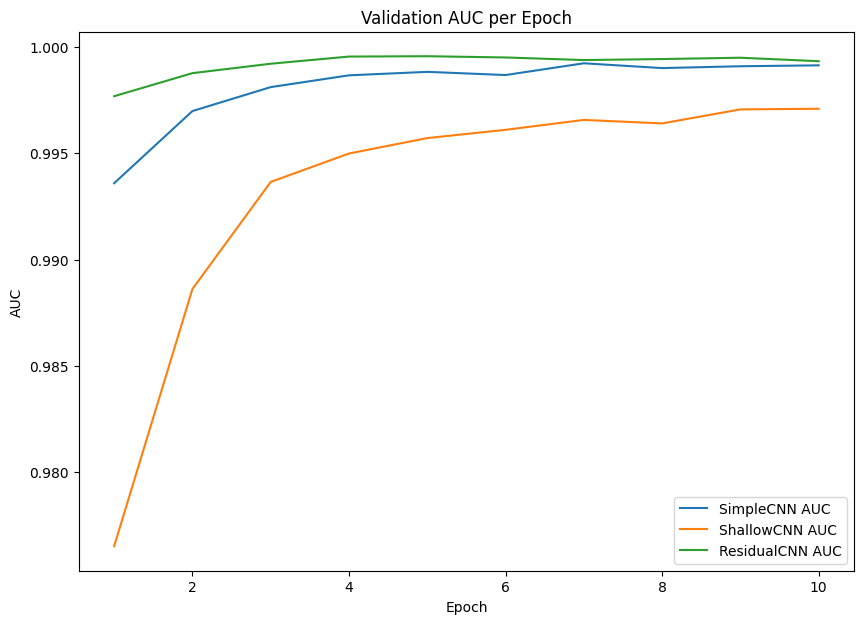

NameError: name 'SimpleCNN' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Đọc dữ liệu lịch sử huấn luyện của 3 mô hình
models = ["SimpleCNN", "ShallowCNN", "ResidualCNN"]
histories = {}
for name in models:
    df = pd.read_csv(f"Model_data/{name}_models_history.csv")
    histories[name] = df

# Vẽ Train/Val Loss
plt.figure(figsize=(15,5))
for name, df in histories.items():
    plt.plot(df["epoch"], df["train_loss"], label=f"{name} Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label=f"{name} Val Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Vẽ Validation Accuracy
plt.figure(figsize=(10,5))
for name, df in histories.items():
    plt.plot(df["epoch"], df["val_acc_pct"], label=f"{name} Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# Vẽ ROC Curve cho từng mô hình (dùng giá trị AUC đã lưu)
plt.figure(figsize=(10,7))
for name, df in histories.items():
    plt.plot(df["epoch"], df["val_auc"], label=f"{name} AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC per Epoch")
plt.legend()
plt.show()

# Confusion Matrix (sử dụng kết quả cuối cùng của validation)
from torch.utils.data import DataLoader
import torch

# Chuẩn bị dữ liệu validation


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for name in models:
    # Load lại mô hình và trọng số
    if name == "SimpleCNN":
        model = SimpleCNN()
    elif name == "ShallowCNN":
        model = ShallowCNN()
    else:
        model = ResidualCNN()
    model.load_state_dict(torch.load(f"weights/{name}_weights.pth"))
    model = model.to(device)
    model.eval()

    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = (outputs > 0.5).float().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["CNV","NORMAL"], yticklabels=["CNV","NORMAL"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

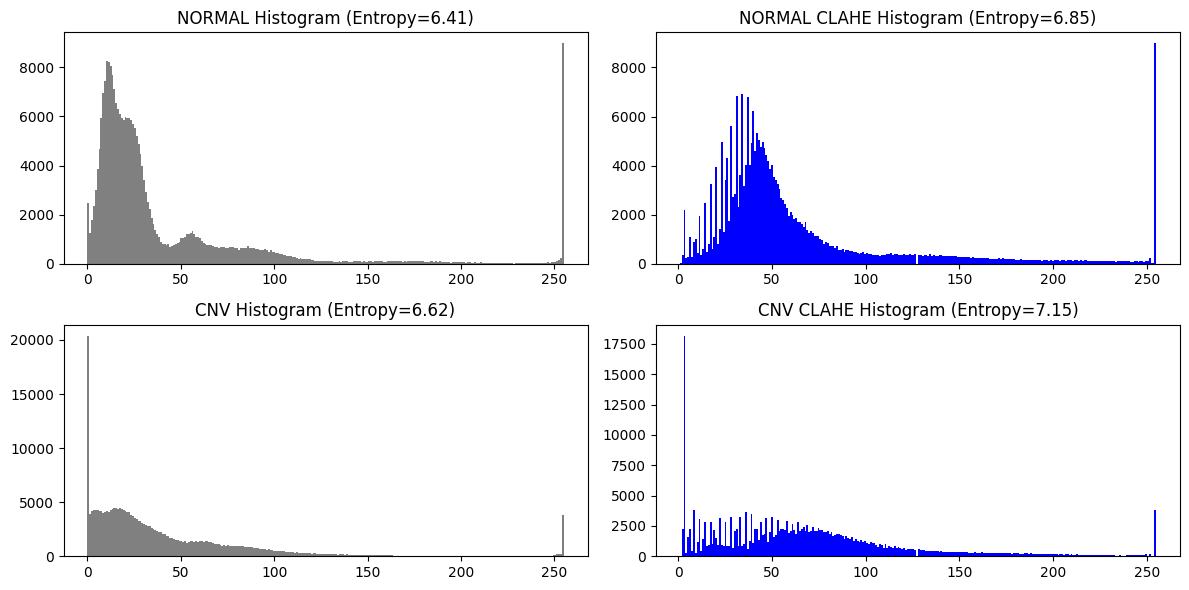

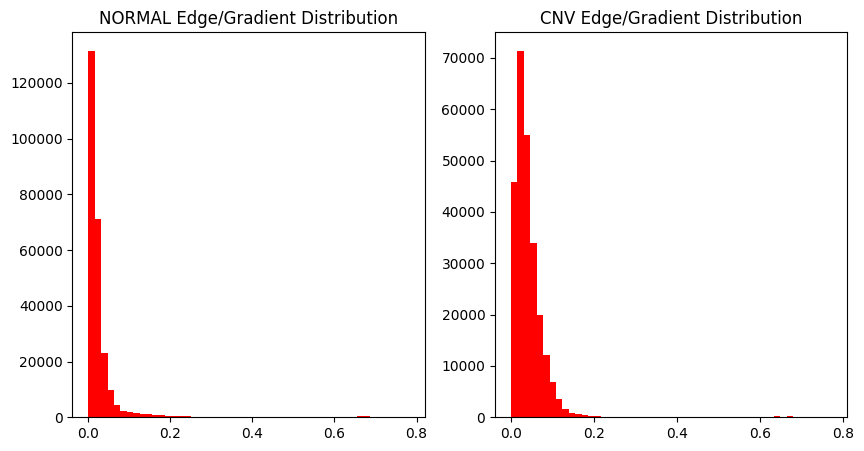

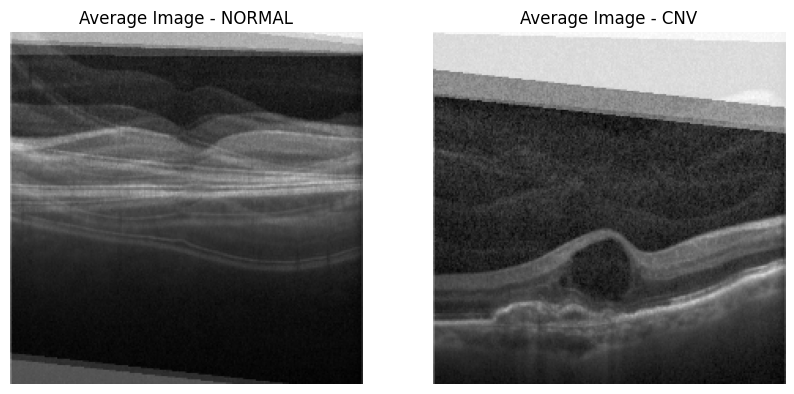

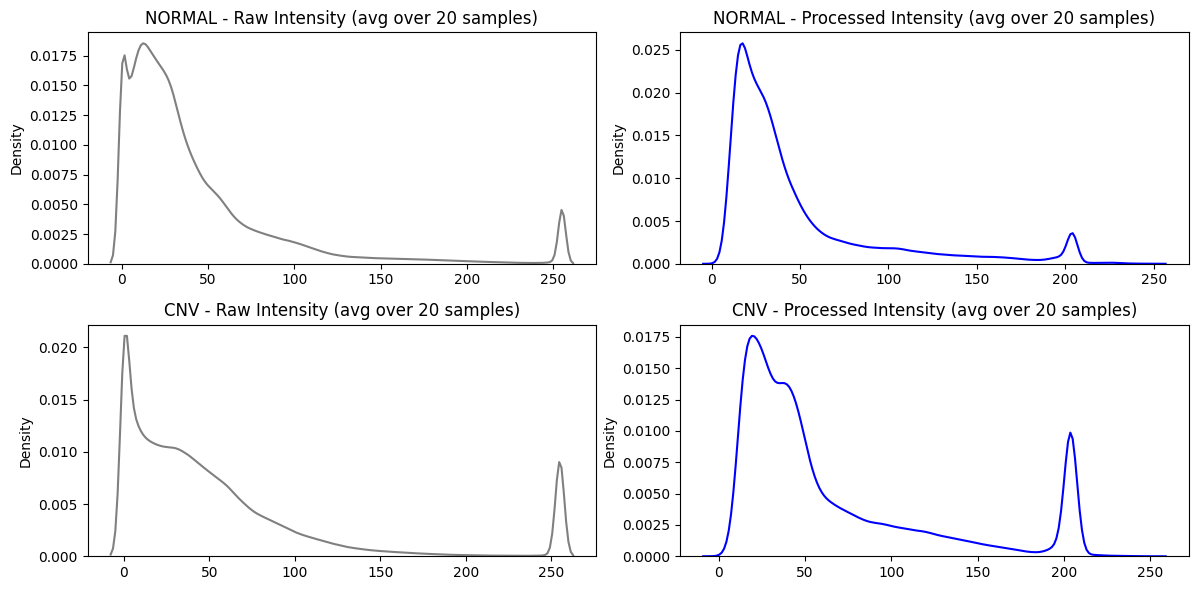

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from skimage.filters import sobel
from skimage.measure import shannon_entropy


DATA_DIR = "Dataset"
categories = ["NORMAL", "CNV"]


sample_images = {}
for cat in categories:
    folder = os.path.join(DATA_DIR, cat)
    files = os.listdir(folder)[:10]  
    sample_images[cat] = [cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE) for f in files]


plt.figure(figsize=(12,6))
for i, cat in enumerate(categories):
    img = sample_images[cat][0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)
    entropy_before = shannon_entropy(img)
    entropy_after = shannon_entropy(img_clahe)

    plt.subplot(2,2,i*2+1)
    plt.hist(img.ravel(), bins=256, color='gray')
    plt.title(f"{cat} Histogram (Entropy={entropy_before:.2f})")

    plt.subplot(2,2,i*2+2)
    plt.hist(img_clahe.ravel(), bins=256, color='blue')
    plt.title(f"{cat} CLAHE Histogram (Entropy={entropy_after:.2f})")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
for i, cat in enumerate(categories):
    img = sample_images[cat][0]
    edges = sobel(img)
    plt.subplot(1,2,i+1)
    plt.hist(edges.ravel(), bins=50, color='red')
    plt.title(f"{cat} Edge/Gradient Distribution")
plt.show()


plt.figure(figsize=(10,5))
for i, cat in enumerate(categories):
    imgs = [cv2.resize(img,(224,224)) for img in sample_images[cat]]
    avg_img = np.mean(imgs, axis=0)
    plt.subplot(1,2,i+1)
    plt.imshow(avg_img, cmap='gray')
    plt.title(f"Average Image - {cat}")
    plt.axis('off')
plt.show()


DATA_DIR = "Dataset"
categories = ["NORMAL", "CNV"]

num_samples = 20  

plt.figure(figsize=(12,6))
for i, cat in enumerate(categories):
    folder = os.path.join(DATA_DIR, cat)
    files = os.listdir(folder)[:num_samples]

    raw_intensities = []
    proc_intensities = []

    for fname in files:
        raw_img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        proc_img = img_proccessing(os.path.join(folder, fname))  
        proc_img = (proc_img.squeeze() * 255).astype(np.uint8)

        raw_intensities.extend(raw_img.ravel())
        proc_intensities.extend(proc_img.ravel())

 
    plt.subplot(2,2,i*2+1)
    sns.kdeplot(raw_intensities, color="gray")
    plt.title(f"{cat} - Raw Intensity (avg over {num_samples} samples)")

    plt.subplot(2,2,i*2+2)
    sns.kdeplot(proc_intensities, color="blue")
    plt.title(f"{cat} - Processed Intensity (avg over {num_samples} samples)")

plt.tight_layout()
plt.show()


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import cv2

class CustomPreprocess:
    def __call__(self, img):
        img = np.array(img)               # PIL → numpy uint8
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        img = cv2.resize(img, (224,224))
        img = cv2.bilateralFilter(img, 9, 75, 75)

        clahe = cv2.createCLAHE(2.0, (8,8))
        img = clahe.apply(img)            # <-- NO ERROR (uint8)

        lap = cv2.Laplacian(img, cv2.CV_64F)
        img = cv2.addWeighted(img, 0.8, cv2.convertScaleAbs(lap), 0.2, 0)

        return img



test_transforms = transforms.Compose([
    CustomPreprocess(),                     # ==> xử lý bằng cv2 trước
    transforms.ToTensor(),                  # ==> rồi mới Tensor
])


test_dataset = datasets.ImageFolder("test", transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_dataset.class_to_idx = {'NORMAL': 0, 'CNV': 1}
test_dataset.samples = [
    (path, 0 if 'NORMAL' in path else 1)
    for path, _ in test_dataset.samples
]

models_to_eval = {
    "SimpleCNN": SimpleCNN(),
    "ShallowCNN": ShallowCNN(),
    "ResidualCNN": ResidualCNN()
}


for name, model in models_to_eval.items():
    weight_path = f"weights/{name}_weights.pth"
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model = model.to(device)
    model.eval()
    models_to_eval[name] = model
    print(f"Loaded weights for {name}")


def evaluate_model(model, loader):
    all_labels = []
    all_preds = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = (outputs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())

    return np.array(all_labels), np.array(all_preds)



plt.figure(figsize=(16, 4))

for i, (name, model) in enumerate(models_to_eval.items(), 1):
    y_true, y_pred = evaluate_model(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','CNV'],
            yticklabels=['NORMAL','CNV'])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


AttributeError: module 'torch' has no attribute '_utils'

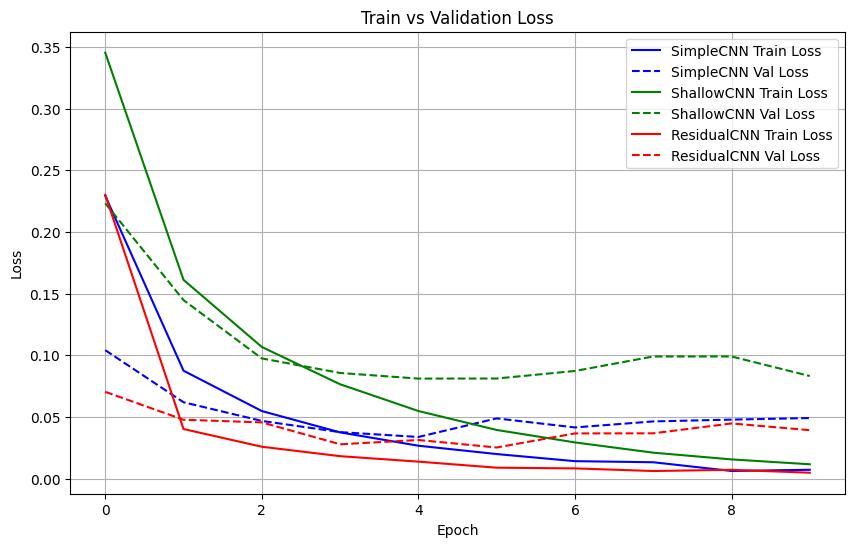

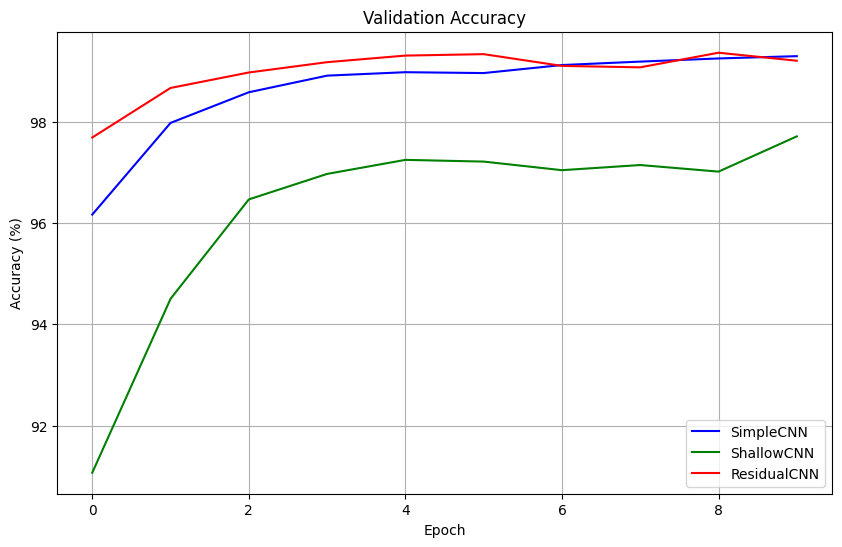

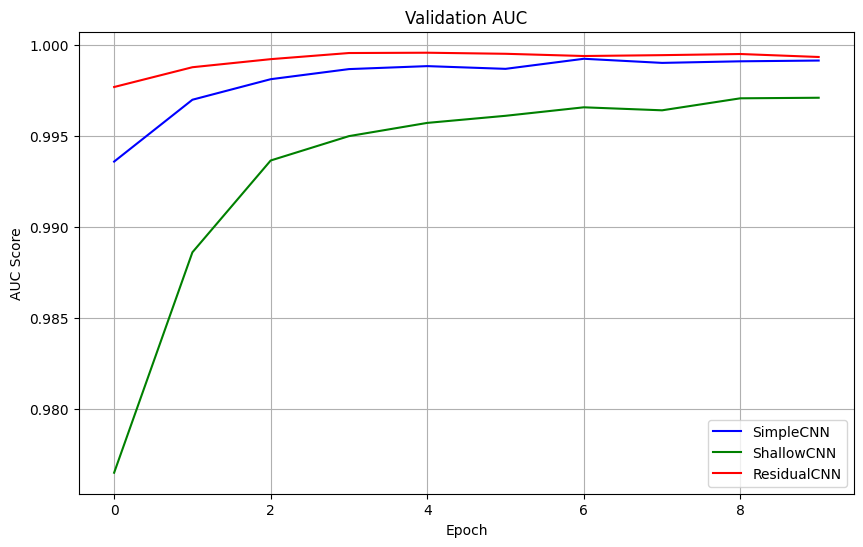

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


SimpleCNN_history = pd.read_csv("Model_data/SimpleCNN_models_history.csv")
ShallowCNN_history = pd.read_csv("Model_data/ShallowCNN_models_history.csv")
ResidualCNN_history = pd.read_csv("Model_data/ResidualCNN_models_history.csv")

history = {
    "SimpleCNN": SimpleCNN_history,
    "ShallowCNN": ShallowCNN_history,
    "ResidualCNN": ResidualCNN_history
}

colors = {
    "SimpleCNN": "blue",
    "ShallowCNN": "green",
    "ResidualCNN": "red"
}


plt.figure(figsize=(10, 6))
for name, stats in history.items():
    plt.plot(stats["train_loss"], label=f"{name} Train Loss", color=colors[name], linestyle="-")
    plt.plot(stats["val_loss"], label=f"{name} Val Loss", color=colors[name], linestyle="--")

plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(10, 6))
for name, stats in history.items():
    plt.plot(stats["val_acc_pct"], label=name, color=colors[name])

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(10, 6))
for name, stats in history.items():
    plt.plot(stats["val_auc"], label=name, color=colors[name])

plt.title("Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(True)
plt.show()


Loaded: weights/SimpleCNN_weights.pth
Loaded: weights/ShallowCNN_weights.pth
Loaded: weights/ResidualCNN_weights.pth


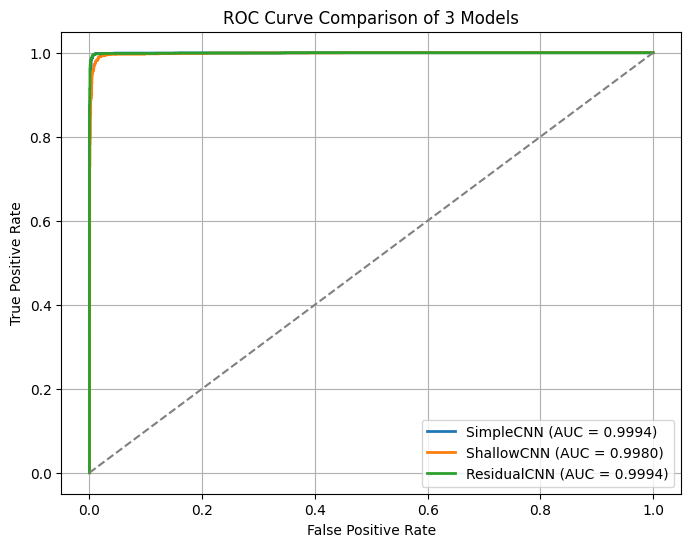

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_to_eval = {
    "SimpleCNN": SimpleCNN(),
    "ShallowCNN": ShallowCNN(),
    "ResidualCNN": ResidualCNN()
}

for name, model in models_to_eval.items():
    weight_path = f"weights/{name}_weights.pth"
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model = model.to(device)
    model.eval()
    models_to_eval[name] = model
    print(f"Loaded: {weight_path}")

def predict_prob(model, loader):
    all_labels = []
    all_probs = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = outputs.cpu().numpy().flatten()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs)

    return np.array(all_labels), np.array(all_probs)

plt.figure(figsize=(8, 6))

for name, model in models_to_eval.items():

    y_true, y_prob = predict_prob(model, test_loader)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    model_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {model_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison of 3 Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
